# TCP Deep Dive: Connections, Reliability, and Congestion Control
**Course:** Introduction to Networking  
**Topics:** TCP Header, Handshake, Flow Control, EWMA/RTO, Congestion Control, CUBIC, QUIC  
**Format:** Worked Problems + Simulation Lab

---

## Overview

This artifact covers the full TCP protocol across two parts:

- **Part 1** — The mechanics of TCP: how connections are established and torn down, how sequence numbers and ACKs provide reliability, how RTT is estimated, and how flow control prevents buffer overflow.
- **Part 2** — Congestion control: how TCP regulates its sending rate in response to network conditions, the evolution from Reno to CUBIC, and modern alternatives like QUIC.

---

# PART 1: Connections, Sequencing, and Flow Control

## Section 1.1 — The TCP Segment Header

TCP is a **transport layer** protocol that provides reliable, ordered, byte-stream delivery over an unreliable IP network. Every TCP segment carries a header with the following key fields:

| Field | Size | Purpose |
|-------|------|---------|
| **Source Port** | 16 bits | Identifies the sending application/socket |
| **Destination Port** | 16 bits | Identifies the receiving application/socket |
| **Sequence Number** | 32 bits | Byte offset of the first byte in this segment |
| **Acknowledgment Number** | 32 bits | Next byte the receiver expects (cumulative ACK) |
| **Header Length** | 4 bits | Size of the header in 32-bit words |
| **Flags** | 9 bits | SYN, ACK, FIN, RST, PSH, URG, ECE, CWR, NS |
| **Receive Window (rwnd)** | 16 bits | How many bytes the receiver can currently accept |
| **Checksum** | 16 bits | Error detection over header + data |
| **Urgent Pointer** | 16 bits | Used with URG flag (rare in practice) |
| **Options** | Variable | Window scaling, timestamps, MSS negotiation |

### Why sequence numbers count bytes, not segments

TCP models data as a continuous **byte stream**, not a sequence of discrete messages. Numbering by bytes allows:
- The receiver to detect gaps and reorder out-of-order segments
- Partial ACKs to be meaningful (ACK 1001 means "I have everything up to byte 1001")
- Segments of different sizes to be handled uniformly

If TCP numbered segments instead, a retransmitted segment with different data (due to MTU changes) would be ambiguous.

---

## Section 1.2 — The Three-Way Handshake

### Concept

Before any data is exchanged, TCP establishes a connection using a **three-way handshake**. This synchronizes sequence numbers on both sides and confirms bidirectional reachability.

```
Client                          Server
  |                               |
  |--- SYN (seq=x) -------------->|   Client picks random ISN x
  |                               |
  |<-- SYN-ACK (seq=y, ack=x+1) -|   Server picks random ISN y, ACKs x
  |                               |
  |--- ACK (ack=y+1) ------------>|   Client ACKs y — connection open
  |                               |
```

**Why are Initial Sequence Numbers (ISNs) randomized?**  
If ISNs were predictable (e.g., always starting at 0), an attacker could forge segments that appear to belong to an existing connection. Randomization makes it infeasible to guess a valid sequence number, preventing **TCP hijacking** and **blind injection attacks**.

### Worked Problem 1 — Trace a Handshake

> **Problem:** A client initiates a TCP connection to a web server. The client picks ISN = 1000, the server picks ISN = 5000. Trace the three-way handshake, showing the Sequence Number, ACK Number, and flags for each segment.

**Solution:**

| Step | Sender | Flags | Seq | Ack | Explanation |
|------|--------|-------|-----|-----|-------------|
| 1 | Client | SYN | 1000 | — | Client opens connection, announces ISN=1000 |
| 2 | Server | SYN, ACK | 5000 | 1001 | Server announces ISN=5000, ACKs client's ISN (1000+1) |
| 3 | Client | ACK | 1001 | 5001 | Client ACKs server's ISN (5000+1), connection established |

Note: SYN and FIN each consume one sequence number even though they carry no data, which is why ACK = ISN + 1.

### ✏️ Practice Problem 1

> A client picks ISN = 3000, server picks ISN = 8000. A second client then connects to the same server and picks ISN = 4500; the server picks ISN = 9200 for this connection.
>
> (a) Trace both handshakes completely (seq, ack, flags for each segment).  
> (b) Why does the server need a different ISN for each connection, even if the same client port is reused shortly after?

a)

client 1 - Seq 3000, Ack DC, Flags: Syn 1


server - Seq 8000, Ack 3001, Flags: Syn 1, Ack 1


client 1 - Seq 3001, Ack 8001, Flags: Ack 1




client 2 - Seq 4500, Ack DC, Flags: Syn 1


server - Seq 9200, Ack 4501, Flags: Syn 1, Ack 1


client 2 - Seq 4501, Ack 9201, Flags: Ack 1

b)


to correctly differentiate between different connections so that even if it is using the same client port old data isn't incorrectly being sent over.

---

## Section 1.3 — Connection Teardown

### Concept

TCP teardown uses a **FIN/ACK exchange**. Because TCP is full-duplex, each direction must be closed independently — this is called a **half-close**.

```
Client                          Server
  |                               |
  |--- FIN (seq=x) -------------->|   Client done sending
  |<-- ACK (ack=x+1) ------------|   Server ACKs — client→server half closed
  |                               |   (server may still send data here)
  |<-- FIN (seq=y) ---------------|   Server done sending
  |--- ACK (ack=y+1) ------------>|   Client ACKs — connection fully closed
  |                               |
  [Client waits in TIME_WAIT for 2*MSL]
```

**RST (Reset):** An abrupt close — no graceful teardown. Used when a connection is invalid or an error occurs. The receiver must discard all buffered data immediately.

**Why does TIME_WAIT exist?**  
After sending the final ACK, the client waits for **2 × MSL (Maximum Segment Lifetime)** before fully closing. This serves two purposes:
1. If the final ACK is lost, the server will retransmit its FIN — TIME_WAIT ensures the client is still around to re-ACK it
2. It prevents old duplicate segments from a previous connection on the same port from being misinterpreted as belonging to a new connection

### Worked Problem 2 — Teardown Trace

> **Problem:** After data transfer, the server decides to close the connection first. The server's current sequence number is 6500, the client's is 2300. Trace the full four-way teardown.

**Solution:**

| Step | Sender | Flags | Seq | Ack | Notes |
|------|--------|-------|-----|-----|-------|
| 1 | Server | FIN, ACK | 6500 | 2300 | Server initiates close |
| 2 | Client | ACK | 2300 | 6501 | Client ACKs FIN (consumes 1 seq number) |
| 3 | Client | FIN, ACK | 2300 | 6501 | Client closes its direction |
| 4 | Server | ACK | 6501 | 2301 | Server ACKs — connection closed |

Client now enters TIME_WAIT and waits 2×MSL before releasing the port.

### ✏️ Practice Problem 2

> (a) What happens if the server sends data between steps 1 and 3 above (between its FIN and the client's FIN)? Is this valid TCP behavior?  
> (b) In what scenario would a host send a RST instead of a FIN? Give a concrete example.

_Your answer here._

a)
It cannot, as it has already sent it's own declaration of finishing. This is not valid TCP behavior. On the other hand, the client can still send before it declares its finish.

b)
Something usually goes wrong when a reset is called for instead, such as a time to live dying on a idling thread.

---

## Section 1.4 — RTT Estimation and RTO (EWMA)

### Concept

TCP needs to know how long to wait before retransmitting a lost segment — this is the **Retransmission Timeout (RTO)**. Setting it correctly requires estimating the current RTT.

TCP uses an **Exponentially Weighted Moving Average (EWMA)** — a discrete-time low-pass filter that smooths out noise while tracking trends:

$$\text{SRTT} \leftarrow (1 - \alpha) \cdot \text{SRTT} + \alpha \cdot \text{RTT}_{\text{sample}}$$

Typically $\alpha = 0.125$ (i.e. 1/8).

**Why track variance (RTTVAR)?**  
SRTT alone is not enough. On a path with high RTT variance, a tight RTO (= SRTT) would cause premature retransmissions on every spike. RTTVAR tracks how much the RTT fluctuates:

$$\text{RTTVAR} \leftarrow (1 - \beta) \cdot \text{RTTVAR} + \beta \cdot |\text{SRTT} - \text{RTT}_{\text{sample}}|$$

Typically $\beta = 0.25$ (i.e. 1/4). The final RTO:

$$\text{RTO} = \text{SRTT} + 4 \cdot \text{RTTVAR}$$

The factor of 4 provides a safety margin that scales with observed variability.

### Worked Problem 3 — EWMA Calculation

> **Problem:** A TCP connection starts with SRTT = 100ms, RTTVAR = 10ms. The next three RTT samples are: 120ms, 80ms, 150ms. Calculate SRTT, RTTVAR, and RTO after each sample. Use α = 0.125, β = 0.25.

**Solution:**

In [1]:
# Worked Problem 3 — EWMA/RTO Calculation

alpha = 0.125
beta  = 0.25

srtt   = 100.0  # ms
rttvar = 10.0   # ms
samples = [120, 80, 150]

print(f"{'Sample':>8} {'RTT':>8} {'SRTT':>10} {'RTTVAR':>10} {'RTO':>10}")
print(f"{'Initial':>8} {'—':>8} {srtt:>10.2f} {rttvar:>10.2f} {srtt + 4*rttvar:>10.2f}")

for i, rtt in enumerate(samples, 1):
    rttvar = (1 - beta)  * rttvar + beta  * abs(srtt - rtt)
    srtt   = (1 - alpha) * srtt   + alpha * rtt
    rto    = srtt + 4 * rttvar
    print(f"{i:>8} {rtt:>8} {srtt:>10.2f} {rttvar:>10.2f} {rto:>10.2f}")

  Sample      RTT       SRTT     RTTVAR        RTO
 Initial        —     100.00      10.00     140.00
       1      120     102.50      12.50     152.50
       2       80      99.69      15.00     159.69
       3      150     105.98      23.83     201.29


**Interpretation:** Notice how SRTT moves slowly toward the true RTT (the low-pass filtering effect), while RTTVAR captures the spread. When RTT spikes to 150ms, RTTVAR grows and the RTO gives extra headroom — preventing a premature retransmit just because of one high-latency sample.

### ✏️ Practice Problem 3

> Start with SRTT = 200ms, RTTVAR = 20ms. Samples arrive: 210ms, 195ms, 400ms, 205ms.
>
> (a) Calculate SRTT, RTTVAR, and RTO after each sample (you can use the code cell below).  
> (b) After the 400ms spike, did the RTO increase enough to avoid a spurious retransmit if the next real RTT is ~210ms? Explain.  
> (c) Why is this EWMA described as a "low-pass filter"? What does it filter out?

In [2]:
# Practice Problem 3 — fill in your values and run

alpha = 0.125
beta  = 0.25

srtt   = 200
rttvar = 20
samples = [210, 195, 400, 205]  

print(f"{'Sample':>8} {'RTT':>8} {'SRTT':>10} {'RTTVAR':>10} {'RTO':>10}")
print(f"{'Initial':>8} {'—':>8} {srtt:>10.2f} {rttvar:>10.2f} {srtt + 4*rttvar:>10.2f}")

for i, rtt in enumerate(samples, 1):
    rttvar = (1 - beta)  * rttvar + beta  * abs(srtt - rtt)
    srtt   = (1 - alpha) * srtt   + alpha * rtt
    rto    = srtt + 4 * rttvar
    print(f"{i:>8} {rtt:>8} {srtt:>10.2f} {rttvar:>10.2f} {rto:>10.2f}")

  Sample      RTT       SRTT     RTTVAR        RTO
 Initial        —     200.00      20.00     280.00
       1      210     201.25      17.50     271.25
       2      195     200.47      14.69     259.22
       3      400     225.41      60.90     469.00
       4      205     222.86      50.78     425.96


b)
yes, the timeout time is long enough.

c)
it is a low pass filter in the sense a massive jump does not destroy the moving average, and a smoothing is done to not be that large of a change.

---

## Section 1.5 — Fast Retransmit and Flow Control

### Fast Retransmit

Waiting for the RTO timer to expire before retransmitting can waste hundreds of milliseconds. **Fast retransmit** is an optimization: if the sender receives **three duplicate ACKs** (the same ACK number repeated 4 times total), it infers that the ACKed segment was lost and retransmits immediately — without waiting for the timer.

**Why three duplicates?**  
A single duplicate ACK might just be caused by reordering (a later segment arriving before an earlier one). Two duplicates is still plausibly reordering. Three duplicates is a strong signal that the segment is genuinely missing — reordering rarely causes that many out-of-order arrivals.

### Flow Control

Flow control prevents the **sender from overwhelming the receiver's buffer**. The receiver advertises its available buffer space in the **rwnd** (receive window) field of every ACK. The sender may have at most `rwnd` bytes of unacknowledged data in flight at any time.

If rwnd = 0, the sender stops transmitting and periodically sends a 1-byte **window probe** to detect when the receiver has freed buffer space.

### Worked Problem 4 — Fast Retransmit Trace

> **Problem:** A sender transmits segments 1–5 (each 100 bytes, so seq 1, 101, 201, 301, 401). Segment 2 (seq=101) is lost. Trace the ACKs the receiver sends, identify when fast retransmit triggers, and state what the sender does.

**Solution:**

| Event | Receiver Gets | Receiver Sends ACK | Notes |
|-------|--------------|-------------------|-------|
| Seg 1 arrives (seq=1) | bytes 1–100 | ACK 101 | Normal |
| Seg 2 lost | — | — | Gap created |
| Seg 3 arrives (seq=201) | bytes 201–300 | ACK 101 | Duplicate ACK #1 — gap detected |
| Seg 4 arrives (seq=301) | bytes 301–400 | ACK 101 | Duplicate ACK #2 |
| Seg 5 arrives (seq=401) | bytes 401–500 | ACK 101 | Duplicate ACK #3 → **Fast Retransmit!** |
| Sender retransmits seg 2 | bytes 101–200 | ACK 501 | Gap filled — ACK jumps to cover all buffered data |

### ✏️ Practice Problem 4

> A sender transmits segments with seq: 1, 501, 1001, 1501, 2001, 2501 (each 500 bytes). Segment seq=1001 is dropped.
>
> (a) Trace all ACKs the receiver sends.  
> (b) At what point does fast retransmit trigger? What does the sender retransmit?  
> (c) After successful retransmission, what ACK does the receiver send and why does it jump ahead?

a)

Receiver sends the ACKs as the following.

ACK 1 (SYN is established)

ACK 501 (1-500 is sent)

ACK 1001 (501-1000 is sent)

ACK 1001 (1001-1500 is dropped)

ACK 1001 (1501-2000 is sent)

ACK 2001 (Lost packed retransmitted)

ACK 2501 (2001-2501 is sent)

b)

Fast retransmit triggers the third time the acknowledgement is sent after the seq up to 2000 is sent.

c)

After successful retransmission the receiver sends an updated ACK as it is still receiving information from the sender and builds the information back once the missing data is given.

---

# PART 2: Congestion Control and the Modern Picture

## Section 2.1 — Why Congestion Control?

**Flow control** (Part 1) protects the *receiver's buffer*. **Congestion control** protects the *network itself*.

Without congestion control, every TCP sender would transmit as fast as possible. When a bottleneck link becomes overloaded, routers drop packets — causing retransmissions — which causes *more* traffic — which causes more drops. This positive feedback loop is called **congestion collapse**, and it nearly brought down the early internet in 1986.

TCP solves this by having each sender maintain a **congestion window (cwnd)** — a self-imposed limit on how much data can be in flight, separate from rwnd. The effective window is:

$$\text{effective window} = \min(\text{cwnd}, \text{rwnd})$$

---

## Section 2.2 — The Three Phases of TCP Congestion Control

### Slow Start
- Begin with cwnd = 1 MSS (Maximum Segment Size)
- For each ACK received, cwnd += 1 MSS → **exponential growth**
- Continue until cwnd reaches **ssthresh** (slow start threshold)

### Congestion Avoidance (AIMD)
- Once cwnd ≥ ssthresh, switch to linear growth
- For each ACK: cwnd += MSS²/cwnd → approximately **+1 MSS per RTT**
- This is the **Additive Increase** phase of AIMD

### Loss Events and Recovery

| Loss Signal | Response |
|-------------|----------|
| **Timeout** | ssthresh = cwnd/2; cwnd = 1 MSS; restart slow start |
| **3 Duplicate ACKs** | ssthresh = cwnd/2; cwnd = ssthresh; enter fast recovery |

A timeout is treated as a more severe signal than triple-dup-ACK, because it implies the network is badly congested (not just a single lost packet).

**Fast Recovery (TCP Reno):** After triple-dup-ACK, cwnd is halved rather than reset to 1. The sender stays in fast recovery, inflating cwnd by 1 MSS per duplicate ACK, until the lost segment is ACKed — this is the **Multiplicative Decrease** of AIMD.

## Section 2.3 — Simulation: cwnd Evolution Over Time

Let's simulate TCP Reno's congestion control and plot the characteristic **sawtooth pattern**.

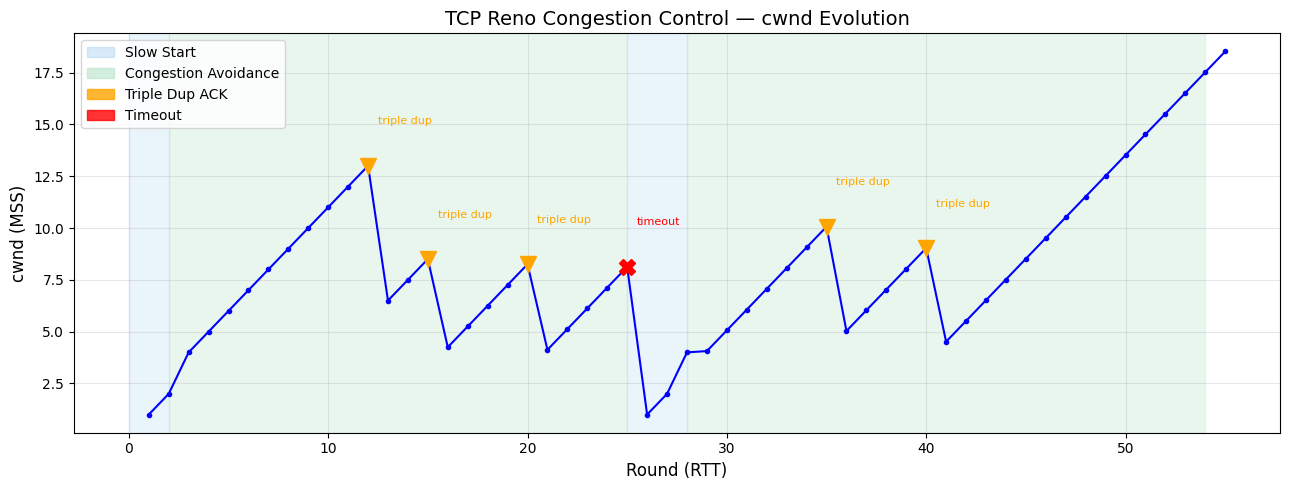

Plot saved as tcp_reno_cwnd.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def simulate_tcp_reno(rounds=60, initial_ssthresh=4, loss_events=None):
    """
    Simulate TCP Reno congestion control.
    loss_events: list of (round, type) where type is 'timeout' or 'triple_dup'
    """
    if loss_events is None:
        loss_events = []
    
    loss_dict = {r: t for r, t in loss_events}
    
    cwnd     = 1.0
    ssthresh = initial_ssthresh
    phase    = 'slow_start'
    
    history = []
    phases  = []
    
    for t in range(1, rounds + 1):
        history.append(cwnd)
        phases.append(phase)
        
        # Check for loss event this round
        if t in loss_dict:
            event = loss_dict[t]
            ssthresh = max(cwnd / 2, 1)
            if event == 'timeout':
                cwnd  = 1.0
                phase = 'slow_start'
            else:  # triple duplicate ACK
                cwnd  = ssthresh
                phase = 'congestion_avoidance'
            continue
        
        # Normal update
        if phase == 'slow_start':
            cwnd *= 2  # double per RTT (exponential)
            if cwnd >= ssthresh:
                cwnd  = ssthresh
                phase = 'congestion_avoidance'
        else:  # congestion avoidance
            cwnd += 1  # +1 MSS per RTT (linear)
    
    return history, phases


# Define loss events: (round_number, 'timeout' or 'triple_dup')
loss_events = [
    (12, 'triple_dup'),
    (25, 'timeout'),
    (40, 'triple_dup'),
    (15, 'triple_dup'),
    (20, 'triple_dup'),
    (35, 'triple_dup'),
]

history, phases = simulate_tcp_reno(rounds=55, initial_ssthresh=4, loss_events=loss_events)

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 5))

phase_colors = {'slow_start': '#AED6F1', 'congestion_avoidance': '#A9DFBF'}
prev_phase = phases[0]
start = 0

for i, phase in enumerate(phases):
    if phase != prev_phase or i == len(phases) - 1:
        ax.axvspan(start, i, alpha=0.25, color=phase_colors[prev_phase], label=prev_phase if start == 0 or prev_phase not in [phases[j] for j in range(start)] else "")
        start = i
        prev_phase = phase

ax.plot(range(1, len(history)+1), history, 'b-o', markersize=3, linewidth=1.5, label='cwnd')

# Mark loss events
for r, etype in loss_events:
    color  = 'red' if etype == 'timeout' else 'orange'
    marker = 'X' if etype == 'timeout' else 'v'
    label  = f'Loss: {etype}'
    ax.plot(r, history[r-1], marker=marker, color=color, markersize=12, zorder=5)
    ax.annotate(etype.replace('_', ' '), xy=(r, history[r-1]),
                xytext=(r+0.5, history[r-1]+2), fontsize=8, color=color)

ax.set_xlabel('Round (RTT)', fontsize=12)
ax.set_ylabel('cwnd (MSS)', fontsize=12)
ax.set_title('TCP Reno Congestion Control — cwnd Evolution', fontsize=14)
ax.grid(True, alpha=0.3)

ss_patch   = mpatches.Patch(color='#AED6F1', alpha=0.5, label='Slow Start')
ca_patch   = mpatches.Patch(color='#A9DFBF', alpha=0.5, label='Congestion Avoidance')
td_patch   = mpatches.Patch(color='orange',  alpha=0.8, label='Triple Dup ACK')
to_patch   = mpatches.Patch(color='red',     alpha=0.8, label='Timeout')
ax.legend(handles=[ss_patch, ca_patch, td_patch, to_patch], loc='upper left')

plt.tight_layout()
plt.savefig('tcp_reno_cwnd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as tcp_reno_cwnd.png")

### ✏️ Experiment: Modify the Simulation

Try changing the `loss_events` list and `initial_ssthresh` above and re-run. Observe:

1. What happens to the sawtooth shape when losses are frequent vs. rare?
2. What's the visual difference between a timeout event and a triple-dup-ACK event in the plot?
3. What happens if you set `initial_ssthresh = 4` (very low)?

_Your observations here._

1. There's simply more sawtooths around, and they're smaller.
2. A timeout causes SS and thus an exponential growth until the SS threshhold.
3. It enters linear growth quickly and becomes very slow to grow.

---

## Section 2.4 — cwnd/ssthresh Trace Problem

### Worked Problem 5 — Manual cwnd Trace

> **Problem:** TCP starts with cwnd=1, ssthresh=16. Trace cwnd and ssthresh for 20 rounds given: timeout at round 10, triple-dup-ACK at round 18.

**Solution:**

In [9]:
# Worked Problem 5 — manual trace table

cwnd     = 1
ssthresh = 8
phase    = 'slow_start'
loss     = {6: 'triple_dup', 14: 'timeout',20: 'triple_dup'}

print(f"{'Round':>6} {'cwnd':>6} {'ssthresh':>10} {'Phase':>20} {'Event'}")
print("-" * 60)

for t in range(1, 25):
    event_str = ""
    if t in loss:
        event_str = loss[t]
        ssthresh  = max(cwnd // 2, 1)
        if loss[t] == 'timeout':
            cwnd  = 1
            phase = 'slow_start'
        else:
            cwnd  = ssthresh
            phase = 'congestion_avoidance'
    elif phase == 'slow_start':
        cwnd *= 2
        if cwnd >= ssthresh:
            cwnd  = ssthresh
            phase = 'congestion_avoidance'
    else:
        cwnd += 1

    print(f"{t:>6} {cwnd:>6} {ssthresh:>10} {phase:>20} {event_str}")

 Round   cwnd   ssthresh                Phase Event
------------------------------------------------------------
     1      2          8           slow_start 
     2      4          8           slow_start 
     3      8          8 congestion_avoidance 
     4      9          8 congestion_avoidance 
     5     10          8 congestion_avoidance 
     6      5          5 congestion_avoidance triple_dup
     7      6          5 congestion_avoidance 
     8      7          5 congestion_avoidance 
     9      8          5 congestion_avoidance 
    10      9          5 congestion_avoidance 
    11     10          5 congestion_avoidance 
    12     11          5 congestion_avoidance 
    13     12          5 congestion_avoidance 
    14      1          6           slow_start timeout
    15      2          6           slow_start 
    16      4          6           slow_start 
    17      6          6 congestion_avoidance 
    18      7          6 congestion_avoidance 
    19      8          6

### ✏️ Practice Problem 5

> TCP starts with cwnd=1 MSS, ssthresh=8. Loss events: triple-dup-ACK at round 6, timeout at round 14, triple-dup-ACK at round 20.
>
> (a) Trace cwnd and ssthresh for 25 rounds (modify and run the code above).  
> (b) At round 14, why does the timeout cause a more dramatic cwnd drop than the triple-dup at round 6?  
> (c) What is the maximum cwnd achieved before the first loss event?

b)
Timeout completely resets the cwnd while a triple-dup only cuts it by half.

c)
A size of 10.

---

## Section 2.5 — TCP Throughput Formula

The steady-state throughput of a TCP Reno connection can be approximated as:

$$\text{Throughput} \approx \frac{0.75 \cdot W_{\max}}{\text{RTT}}$$

Where $W_{\max}$ is the window size at the point of loss. A more general form incorporating loss rate $p$:

$$\text{Throughput} \approx \frac{1.22 \cdot \text{MSS}}{\text{RTT} \cdot \sqrt{p}}$$

**Key insight:** throughput scales inversely with RTT. Two flows with the same loss rate but different RTTs will get *different* throughputs — longer RTT flows are penalized. This is TCP's **RTT unfairness**.

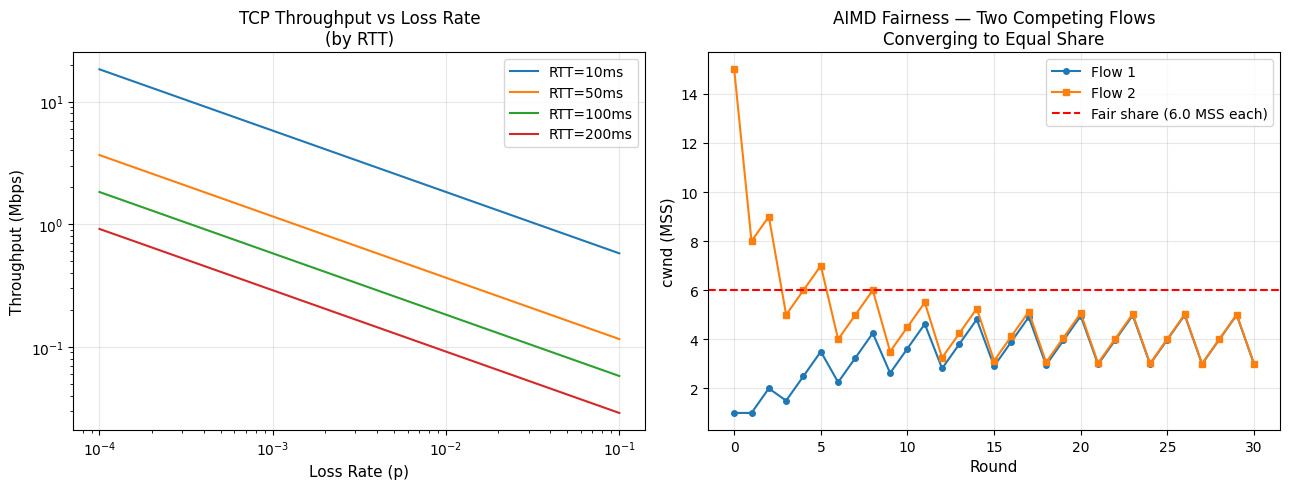

Plot saved as tcp_throughput_fairness.png


In [10]:
import numpy as np
import matplotlib.pyplot as plt

MSS = 1500  # bytes

loss_rates = np.logspace(-4, -1, 200)  # 0.0001 to 0.1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Throughput vs Loss Rate for different RTTs
ax = axes[0]
for rtt_ms in [10, 50, 100, 200]:
    rtt_s = rtt_ms / 1000
    throughput_mbps = (1.22 * MSS / (rtt_s * np.sqrt(loss_rates))) / 1e6
    ax.loglog(loss_rates, throughput_mbps, label=f'RTT={rtt_ms}ms')

ax.set_xlabel('Loss Rate (p)', fontsize=11)
ax.set_ylabel('Throughput (Mbps)', fontsize=11)
ax.set_title('TCP Throughput vs Loss Rate\n(by RTT)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: AIMD Fairness — two flows converging
ax2 = axes[1]
w1, w2 = 1.0, 15.0  # starting windows (unfair)
capacity = 12.0
w1s, w2s = [w1], [w2]

for _ in range(30):
    w1 += 1; w2 += 1  # additive increase
    if w1 + w2 > capacity:
        w1 *= 0.5; w2 *= 0.5  # multiplicative decrease
    w1s.append(w1); w2s.append(w2)

ax2.plot(w1s, label='Flow 1', marker='o', markersize=4)
ax2.plot(w2s, label='Flow 2', marker='s', markersize=4)
ax2.axhline(y=capacity/2, color='red', linestyle='--', label=f'Fair share ({capacity/2} MSS each)')
ax2.set_xlabel('Round', fontsize=11)
ax2.set_ylabel('cwnd (MSS)', fontsize=11)
ax2.set_title('AIMD Fairness — Two Competing Flows\nConverging to Equal Share', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tcp_throughput_fairness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as tcp_throughput_fairness.png")

### ✏️ Practice Problem 6 — Throughput Calculation

> (a) A TCP flow has RTT = 50ms and loss rate p = 0.001. Calculate its approximate throughput using the formula above (MSS = 1500 bytes).  
> (b) A second flow has RTT = 200ms and the same loss rate. What is its throughput? What is the ratio of the two throughputs?  
> (c) Looking at the AIMD fairness plot: why do the two flows converge to equal shares regardless of their starting windows? What property of AIMD guarantees this?

_Your answer here._

a)

About 9.26 Mbps

b)

About 2.31 Mbps, the ratio is 1:4 which means the RTT scales linearly with throughput.

c)

Competing flows decreases multiplicatively while a RTT round increases additivitely. This causes low windows to increase and large windows to drop.

---

## Section 2.6 — CUBIC vs Reno, ECN, and QUIC

### Why Reno Fails on High-BDP Paths

The **Bandwidth-Delay Product (BDP)** is the amount of data "in flight" on a path at full utilization:

$$\text{BDP} = \text{Bandwidth} \times \text{RTT}$$

On a 1 Gbps link with RTT = 100ms, BDP = 12.5 MB. To fully utilize this link, cwnd must reach ~8300 MSS. With Reno's linear growth of +1 MSS/RTT, recovering from a loss event would take **8300 RTTs** (~14 minutes). This makes Reno useless on modern high-speed paths.

**Window Scaling** (a TCP option) extends rwnd beyond the 16-bit header limit (max 65KB) to support large BDP paths — but it doesn't fix Reno's slow growth rate.

### CUBIC

CUBIC (default in Linux since 2.6.19) replaces Reno's linear growth with a **cubic function of time since last loss**:

$$W(t) = C(t - K)^3 + W_{\max}$$

Where $K$ is the time it would take to reach $W_{\max}$ from the post-loss window. Key behaviors:
- Grows **aggressively** when far below $W_{\max}$ (cubic curve rises steeply)
- Slows growth near $W_{\max}$ (plateau — probing carefully)
- Grows aggressively again if no loss (exploring beyond old max)
- **RTT-independent** — CUBIC's window growth depends only on real time, not RTT count, fixing Reno's RTT unfairness

### ECN — Explicit Congestion Notification

Loss-based congestion signals (like Reno/CUBIC use) are reactive — they only know congestion happened *after* a packet was dropped. **ECN** is proactive:

1. Routers mark packets (set ECN bits in IP header) when their queue is building up — *before* dropping
2. The receiver echoes the mark back to the sender in the TCP header (ECE flag)
3. The sender reacts as if a triple-dup-ACK occurred — without any actual packet loss

This avoids the latency cost of waiting for a drop and retransmission, making ECN especially valuable for low-latency applications.

### QUIC — Rethinking the Transport Layer

QUIC is a transport protocol built on UDP, developed by Google and now standardized as RFC 9000. It addresses several structural TCP limitations:

| TCP Problem | QUIC Solution |
|-------------|---------------|
| TLS handshake adds 1–2 RTTs on top of TCP handshake | Combined crypto + transport handshake (0-RTT or 1-RTT) |
| Head-of-line blocking: one lost packet stalls all streams | Independent streams — loss in one doesn't block others |
| Ossification: middleboxes inspect/modify TCP headers | Encrypted headers — only endpoints can read them |
| Connection tied to IP:port — breaks on network change | Connection IDs — survives IP address changes (e.g. WiFi → LTE) |

QUIC is the transport layer underneath HTTP/3, and now carries a significant fraction of internet traffic.

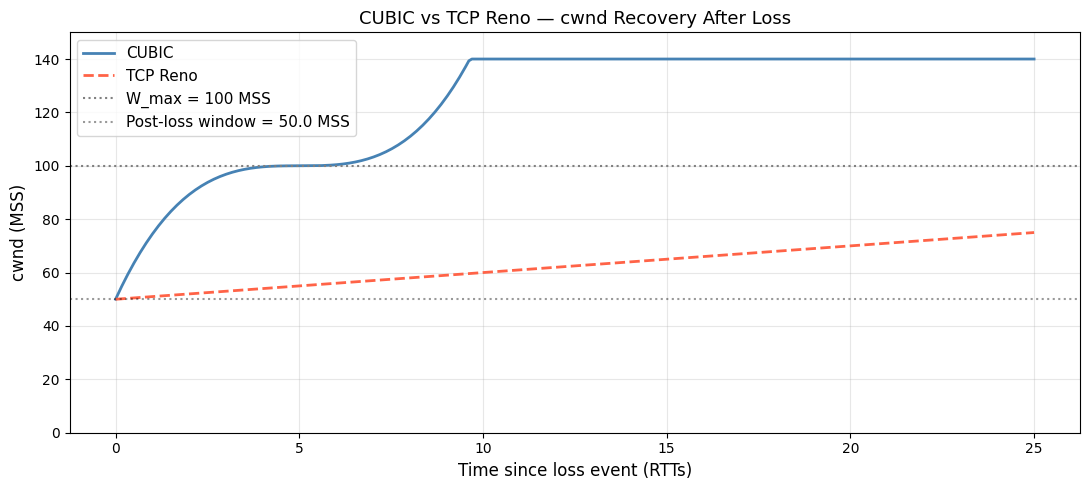

Plot saved as cubic_vs_reno.png


In [12]:
# Visualize CUBIC vs Reno growth after a loss event
import numpy as np
import matplotlib.pyplot as plt

W_max = 100   # window at loss
W_post = W_max * 0.5  # window after multiplicative decrease
C = 0.4       # CUBIC scaling factor
# K: time to reach W_max from W_post
K = ((W_max - W_post) / C) ** (1/3)

t = np.linspace(0, 25, 300)  # time since loss (RTTs)

cubic = np.minimum(C * (t - K)**3 + W_max, W_max * 1.4)  # CUBIC window
reno  = W_post + t  # Reno: linear +1/RTT

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(t, cubic, label='CUBIC', color='steelblue', linewidth=2)
ax.plot(t, reno,  label='TCP Reno', color='tomato', linewidth=2, linestyle='--')
ax.axhline(y=W_max, color='gray', linestyle=':', label=f'W_max = {W_max} MSS')
ax.axhline(y=W_post, color='black', linestyle=':', alpha=0.4, label=f'Post-loss window = {W_post} MSS')

ax.set_xlabel('Time since loss event (RTTs)', fontsize=12)
ax.set_ylabel('cwnd (MSS)', fontsize=12)
ax.set_title('CUBIC vs TCP Reno — cwnd Recovery After Loss', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, W_max * 1.5)

plt.tight_layout()
plt.savefig('cubic_vs_reno.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as cubic_vs_reno.png")

### ✏️ Practice Problem 7 — Analysis Questions

> (a) From the CUBIC vs Reno plot: at what approximate RTT after the loss does CUBIC surpass Reno? What does CUBIC do near W_max that Reno doesn't?  
> (b) A datacenter link has bandwidth = 10 Gbps and RTT = 1ms. Calculate the BDP. How many MSS (1500 bytes) must cwnd reach to fully utilize this link?  
> (c) Explain in your own words why ECN is "preferable to loss-based congestion signals" — what specifically is avoided?  
> (d) HTTP/3 uses QUIC instead of TCP. Name one scenario where QUIC's connection migration would make a noticeable difference to a user, and explain why TCP would fail in that scenario.

_Your answers here._

a)

CUBIC surpasses Reno immediately due to its cubic scaling. It also hangs around at W_max before going higher which Reno does not.

b)

10e9 * 0.001 = e7 bits = 125000 bytes

125000 bytes / 1500 bytes per MSS = 834 MSS.

c) 

With loss based signals, the problem is by the time the signal is received, the network has already hit its limit. And by the time the congestion order is done, the congestion might have cleared up. ECN fixes this by warning ahead of time and stopping the congestion that would actually fill the server up.

d)

If you switch networks, TCP would not have the matching IP and fail, but QUIC would still have the connection address and verify the connection.

---

## Appendix: Quick Reference

| Concept | Formula / Rule |
|---------|----------------|
| EWMA (SRTT) | `SRTT = 0.875·SRTT + 0.125·sample` |
| RTTVAR | `RTTVAR = 0.75·RTTVAR + 0.25·\|SRTT - sample\|` |
| RTO | `RTO = SRTT + 4·RTTVAR` |
| Effective window | `min(cwnd, rwnd)` |
| TCP throughput | `≈ 1.22·MSS / (RTT·√p)` |
| BDP | `Bandwidth × RTT` |
| Slow start | cwnd doubles each RTT until ssthresh |
| Cong. avoidance | cwnd +1 MSS per RTT |
| On timeout | ssthresh = cwnd/2; cwnd = 1 |
| On 3×dup ACK | ssthresh = cwnd/2; cwnd = ssthresh |
| CUBIC growth | `W(t) = C(t-K)³ + W_max` |